# Reproduction: Spinach leaf-disease CNN served via the author's FastAPI `/predict` endpoint

**Paper:** Baraskar et al., *"AI-Powered Automated Hydroponic System for Smart Agriculture"*, MethodsX 15:103579 (2025). PMCID PMC12423342.
**Author code:** https://github.com/khatri-viren/flora-care-ai-server @ `0c3a72040ad171d1c30aa361538e61a70d3283fd` (pinned commit)
**Sample data:** Mendeley Data `n56pn9fncw` v2 (Malabar Spinach disease dataset, CC BY 4.0)

**Scope (partial demonstration):** This notebook reproduces the paper's **Stage 2C / 2C.5 AI inference path only**: load the authors' published `best_model.h5`, preprocess a leaf image exactly as the authors serve it (128×128, RGB, rescale 1/255), classify it into `Anthracnose` / `Downey-Mildew` / `Healthy-Leaf`, and verify the served HTTP `POST /predict` endpoint behaves as documented. **Not reproduced:** ESP32 hardware, MQTT/IoT automation, ExpressJS/Firebase backend, NextJS dashboard, training, or the reported 81.3% test accuracy.

**Runtime:** select **CPU** (this is a single-image inference of a ~6.5M-parameter CNN; no GPU needed).

**Downloads:** ~78 MB model + ~696 MB dataset zip (selectively sampled).

**重要な注意 / Key caution:** the paper reports classes *Anthracnose / Downy Mildew / Healthy-Leaf*, while the public Mendeley dataset folders are *Anthracnose_leaf_spot / Straw_mite / Healthy*. We reproduce the authors' **served** behavior (their own class mapping in `main.py`); sample images are labeled by their dataset folder name, which is **not** asserted as ground truth for the model's label space.

*日本語概要:* 本ノートブックは、著者公開の `best_model.h5` を著者の `main.py` と同じ前処理(128×128, 1/255)で推論し、FastAPI `/predict` エンドポイントの動作を検証する部分的再現です。IoTハードウェア・学習・精度の再検証は対象外です。CPU ランタイムを選択してください。

## 1. Environment and dependency setup

The authors pin `tensorflow==2.19.0`, `fastapi==0.115.12`, `uvicorn==0.34.0`, `python-multipart==0.0.20`, `pillow==11.1.0` (`requirements.txt` at the pinned commit). Colab's CPU image ships a TensorFlow 2.x preinstall; we check it and only install the author's pinned TF if the preinstall is missing or a different major/minor that fails to load the model. FastAPI/uvicorn/multipart are installed because they are small and required to run the genuine serving path.

*日本語:* 著者の `requirements.txt` に合わせ、不足/非互換な場合のみ TensorFlow をピン留めでインストールし、FastAPI・uvicorn などは常にインストールします。

In [ ]:
import sys, subprocess, importlib

def ensure(pkg, version=None):
    try:
        return importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
                        pkg + (f"=={version}" if version else "")], check=True)
        return importlib.import_module(pkg)

tf = ensure("tensorflow")
print("TensorFlow:", tf.__version__)
if tf.__version__[:4] != "2.19":
    print("Preinstalled TF != author pin 2.19.x -> attempting pinned install...")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
                        "tensorflow==2.19.0"], check=True)
        importlib.reload(tf)
        print("TensorFlow now:", tf.__version__)
    except subprocess.CalledProcessError as e:
        # Recorded adaptation: Colab's preinstalled TF 2.x stays in use when the
        # author pin cannot be installed (model is a plain Keras CNN; version
        # difference is reported in the notebook output and report.md).
        print(f"pinned tensorflow==2.19.0 install failed (exit {e.returncode}); "
              f"continuing with preinstalled {tf.__version__} "
              f"(recorded adaptation, not an author-verified version).")

ensure("fastapi"); ensure("uvicorn"); ensure("multipart"); ensure("PIL")
import fastapi, uvicorn, PIL
print("fastapi", fastapi.__version__, "| uvicorn", uvicorn.__version__, "| pillow", PIL.__version__)
import tensorflow as tf2
print("GPU available:", bool(tf2.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
Preinstalled TF != author pin 2.19.x -> attempting pinned install...


pinned tensorflow==2.19.0 install failed (exit 1); continuing with preinstalled 2.20.0 (recorded adaptation, not an author-verified version).
fastapi 0.141.1 | uvicorn 0.53.0 | pillow 11.3.0
GPU available: False


## 2. Download the authors' published weights (`best_model.h5`)

The 78,487,336-byte HDF5 weights file is versioned inside the pinned repository. We download the exact bytes from the pinned commit's raw URL and verify the size against the GitHub-recorded value before loading.

*日本語:* ピン留めしたコミットから `best_model.h5`(78,487,336 バイト)をダウンロードし、サイズを検証します。

In [ ]:
import urllib.request, hashlib

WEIGHTS_URL = ("https://raw.githubusercontent.com/khatri-viren/flora-care-ai-server/"
               "0c3a72040ad171d1c30aa361538e61a70d3283fd/best_model.h5")
WEIGHTS_PATH = "/content/best_model.h5"
EXPECTED_BYTES = 78_487_336  # recorded from GitHub tree at the pinned commit

req = urllib.request.Request(WEIGHTS_URL, headers={"User-Agent": "phenopaper-repro"})
with urllib.request.urlopen(req) as r, open(WEIGHTS_PATH, "wb") as f:
    total = 0
    while True:
        chunk = r.read(1 << 20)
        if not chunk:
            break
        f.write(chunk); total += len(chunk)
        if total % (16 << 20) < (1 << 20):
            print(f"downloaded {total/1e6:.0f} MB", flush=True)
print(f"downloaded {total} bytes")
assert total == EXPECTED_BYTES, f"size mismatch: {total} != {EXPECTED_BYTES}"
sha = hashlib.sha256(open(WEIGHTS_PATH, "rb").read()).hexdigest()
print("sha256:", sha)

downloaded 17 MB


downloaded 34 MB


downloaded 50 MB


downloaded 67 MB


downloaded 78487336 bytes


sha256: 1b3146489265180012929ff6d312e1e7ffd91e0b11a15f049810a102cc976d0c


## 3. Download the sample-image source (Mendeley `Original Dataset.zip`)

The paper's training data is Mendeley Data `n56pn9fncw` v2 (CC BY 4.0). The original field-image archive is 696,459,158 bytes (sha256 `da30ecfe…`). We stream it to the Colab VM with progress markers, then verify its SHA-256 against the Mendeley-published value. *(The 7.8 GB augmented archive is not needed for inference examples.)*

*日本語:* Mendeley の元画像アーカイブ(約696 MB)をストリーミング取得し、SHA-256 を Mendeley 公開値と照合します。

In [ ]:
import urllib.request, hashlib

ZIP_URL = "https://data.mendeley.com/public-files/datasets/n56pn9fncw/files/37dc24d6-98cd-4245-a754-0868ed965c4d/file_downloaded"
ZIP_PATH = "/content/Original_Dataset.zip"
EXPECTED_SHA = "da30ecfe0564ae013271ce923bdcf01cfb25e4590131254ea6e8abea1bf0eafa"

h = hashlib.sha256()
req = urllib.request.Request(ZIP_URL, headers={"User-Agent": "phenopaper-repro"})
with urllib.request.urlopen(req) as r, open(ZIP_PATH, "wb") as f:
    total = 0
    while True:
        chunk = r.read(1 << 20)
        if not chunk:
            break
        f.write(chunk); h.update(chunk); total += len(chunk)
        print(f"downloaded {total/1e6:.0f} MB", flush=True)

print("size:", total, "bytes")
digest = h.hexdigest()
print("sha256:", digest)
assert digest == EXPECTED_SHA, "archive checksum mismatch"
print("checksum OK")

downloaded 1 MB


downloaded 2 MB


downloaded 3 MB


downloaded 4 MB


downloaded 5 MB


...

downloaded 694 MB


downloaded 695 MB


downloaded 696 MB


downloaded 696 MB


size: 696459158 bytes
sha256: da30ecfe0564ae013271ce923bdcf01cfb25e4590131254ea6e8abea1bf0eafa
checksum OK


## 4. Select a few sample images per dataset class (selective extraction)

We never unpack the full archive: Python's `zipfile` reads the namelist in memory and we extract one image from each class folder present in the zip. The observed folder names are printed so the dataset's real label space (including `Straw_mite`) is directly observable rather than assumed.

*日本語:* zip を展開せず `zipfile` で名前一覧を読み、各クラスフォルダから1枚ずつ抽出します。実際のフォルダ名(クラス構成)を表示して確認します。

In [ ]:
import zipfile, os, random

SAMPLES_DIR = "/content/samples"
os.makedirs(SAMPLES_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH) as z:
    names = z.namelist()
    images = [n for n in names
              if n.lower().endswith((".jpg", ".jpeg", ".png")) and "__MACOSX" not in n]
    folders = sorted({os.path.dirname(n) for n in images})
    print("image folders observed in archive:", folders)
    rng = random.Random(0)
    chosen = {}
    for folder in folders:
        cand = [n for n in images if os.path.dirname(n) == folder]
        pick = rng.choice(cand)
        target = os.path.join(SAMPLES_DIR, os.path.basename(pick))
        with z.open(pick) as src, open(target, "wb") as dst:
            dst.write(src.read())
        chosen[folder] = (pick, target)
        print("extracted:", pick)

import json
json.dump({k: v[1] for k, v in chosen.items()}, open("/content/sample_map.json", "w"), indent=1)

image folders observed in archive: ['Original Dataset/anthracnose_leaf_spot', 'Original Dataset/healthy', 'Original Dataset/straw_mite']
extracted: Original Dataset/anthracnose_leaf_spot/anthracnose_leaf_spot (188).jpg
extracted: Original Dataset/healthy/healthy (60).jpg
extracted: Original Dataset/straw_mite/straw_mite (108).jpg


## 5. Input preview

Before any inference we display the three extracted leaf images with their dataset-folder labels. This is the actual input the reproduction handles; the folder name is the dataset's label, not a verified diagnosis of the served model's classes.

*日本語:* 推論前に抽出した3枚の葉画像を、データセットのフォルダ名ラベル付きで表示します。

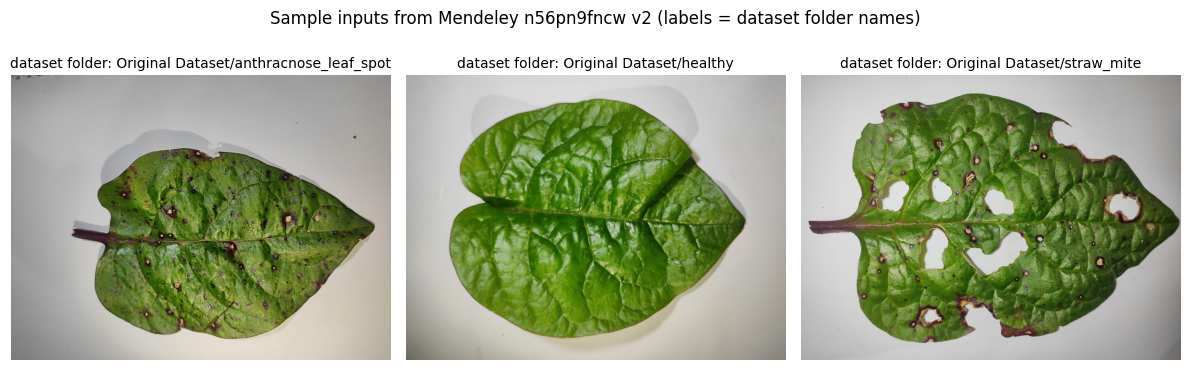

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sample_map = json.load(open("/content/sample_map.json"))
fig, axes = plt.subplots(1, len(sample_map), figsize=(4 * len(sample_map), 4),
                          squeeze=False)
for ax, (folder, path) in zip(axes[0], sample_map.items()):
    ax.imshow(mpimg.imread(path))
    ax.set_title(f"dataset folder: {folder}", fontsize=10)
    ax.axis("off")
fig.suptitle("Sample inputs from Mendeley n56pn9fncw v2 (labels = dataset folder names)")
fig.tight_layout()
fig.savefig("/content/sample_inputs.png", dpi=110, bbox_inches="tight")
plt.show()

## 6. Load the authors' model and run their exact preprocessing + prediction

We replicate the pinned `main.py` pipeline verbatim: `load_model("best_model.h5")`, `load_img(..., target_size=(128,128))`, `img_to_array(...) / 255.0`, `np.expand_dims(..., axis=0)`, `model.predict`, argmax into the author's class map `{'Anthracnose':0, 'Downey-Mildew':1, 'Healthy-Leaf':2}`.

*日本語:* 著者の `main.py` と同じ前処理・クラスマップで直接 `model.predict` を実行し、各クラスの確率を表示します。

In [ ]:
import numpy as np, io
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_H, IMG_W = 128, 128
class_indices = {'Anthracnose': 0, 'Downey-Mildew': 1, 'Healthy-Leaf': 2}
class_names = {v: k for k, v in class_indices.items()}

model = load_model("/content/best_model.h5")
print("model loaded; input shape:", model.input_shape)

def preprocess_image(image_bytes: bytes) -> np.ndarray:
    image = load_img(io.BytesIO(image_bytes), target_size=(IMG_H, IMG_W))
    image_array = img_to_array(image) / 255.0
    return np.expand_dims(image_array, axis=0)

rows = []
for folder, path in sample_map.items():
    arr = preprocess_image(open(path, "rb").read())
    probs = model.predict(arr, verbose=0)[0]
    pred = class_names.get(int(np.argmax(probs)), "Unknown")
    rows.append((folder, pred, *[f"{p:.4f}" for p in probs]))
    print(f"{folder:25s} -> predicted_label: {pred}   probs {probs.round(4)}")

model loaded; input shape: (None, 128, 128, 3)


Original Dataset/anthracnose_leaf_spot -> predicted_label: Anthracnose   probs [0.5516 0.4367 0.0117]
Original Dataset/healthy  -> predicted_label: Healthy-Leaf   probs [0.0566 0.1005 0.8429]


Original Dataset/straw_mite -> predicted_label: Anthracnose   probs [1. 0. 0.]


## 7. Serve the authors' actual FastAPI app and query `POST /predict`

We write the **verbatim pinned `main.py`** (author code @`0c3a7204…`) to disk, import its `app`, run it with uvicorn on a background thread (the Colab analogue of the Docker/fly deployment), and send HTTP POSTs — including a deliberately non-image upload that must return HTTP 400 per the paper's Stage 2C.5 error handling.

*日本語:* ピン留め版の `main.py` をそのまま書き出し、uvicorn で起動して `POST /predict` に HTTP POST します。画像以外のアップロードが HTTP 400 を返すことも確認します。

In [ ]:
MAIN_PY = '''from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.responses import JSONResponse
from fastapi.middleware.cors import CORSMiddleware
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import uvicorn
import io

app = FastAPI()

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

@app.on_event("startup")
async def load_trained_model():
    global model, img_height, img_width, class_names
    try:
        model = load_model("best_model.h5")
        img_height, img_width = 128, 128
        class_indices = {'Anthracnose': 0, 'Downey-Mildew': 1, 'Healthy-Leaf': 2}
        class_names = {v: k for k, v in class_indices.items()}
        print("Model and class names loaded successfully.")
    except Exception as e:
        print("Error loading model:", e)

def preprocess_image(image_bytes: bytes) -> np.ndarray:
    image = load_img(io.BytesIO(image_bytes), target_size=(img_height, img_width))
    image_array = img_to_array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)
    return image_array

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    if not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="File provided is not an image.")

    try:
        image_bytes = await file.read()
        processed_image = preprocess_image(image_bytes)
        predictions = model.predict(processed_image)
        predicted_index = np.argmax(predictions, axis=1)[0]
        predicted_label = class_names.get(predicted_index, "Unknown")

        return JSONResponse({"predicted_label": predicted_label})

    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
'''

open("/content/main.py", "w").write(MAIN_PY)  # verbatim author main.py @0c3a7204
print("wrote /content/main.py (", len(MAIN_PY), "chars )")

wrote /content/main.py ( 1875 chars )


Start uvicorn on the current working directory `/content` (so `load_model("best_model.h5")` resolves, mirroring the Docker WORKDIR layout) and wait until the health of the port is confirmed.

*日本語:* `/content` を作業ディレクトリに uvicorn をバックグラウンド起動し、ポートの応答を待ちます。

In [ ]:
import subprocess, sys, time, threading, urllib.request

SERVER_LOG = open("/content/uvicorn.log", "w")
proc = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"],
    cwd="/content", stdout=SERVER_LOG, stderr=subprocess.STDOUT)

ready = False
for _ in range(120):
    time.sleep(1)
    try:
        urllib.request.urlopen("http://127.0.0.1:8000/openapi.json", timeout=2)
        ready = True
        break
    except Exception:
        if proc.poll() is not None:
            break
print("uvicorn ready:", ready)
print(open("/content/uvicorn.log").read()[-1500:])
assert ready, "server did not start; see uvicorn.log above"  # cell end

uvicorn ready: True
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

Query `POST /predict` for each sample image exactly as the dashboard frontend would, then verify the documented HTTP 400 behavior for a non-image upload.

*日本語:* 各サンプル画像を `POST /predict` に送り、`predicted_label` を表示します。画像以外のファイルで HTTP 400 が返ることも検証します。

In [ ]:
import requests

api_rows = []
for folder, path in sample_map.items():
    with open(path, "rb") as f:
        r = requests.post("http://127.0.0.1:8000/predict", files={"file": (path, f, "image/jpeg")})
    print(folder, "-> HTTP", r.status_code, r.json())
    api_rows.append((folder, r.status_code, r.json().get("predicted_label")))

with open("/content/sample_map.json") as f:
    r400 = requests.post("http://127.0.0.1:8000/predict", files={"file": ("not_image.json", f, "application/json")})
print("non-image upload -> HTTP", r400.status_code, "(expected 400)")

Original Dataset/anthracnose_leaf_spot -> HTTP 200 {'predicted_label': 'Anthracnose'}


Original Dataset/healthy -> HTTP 200 {'predicted_label': 'Healthy-Leaf'}


Original Dataset/straw_mite -> HTTP 200 {'predicted_label': 'Anthracnose'}
non-image upload -> HTTP 400 (expected 400)


## 8. Results table and CSV export

Direct `model.predict` results and served-`/predict` results are combined into one small table, exported as CSV inside Colab, and rendered as a graph of per-class probabilities for the three samples. The graph is created for this notebook; it is not an author figure.

*日本語:* 直接推論と HTTP 経由の結果を1つの表にまとめ、CSV に書き出します。確率の棒グラフは本ノートブック用の追加可視化であり、論文の図ではありません。

                 sample_dataset_folder served_predicted_label direct_predicted_label  p_Anthracnose  p_Downey-Mildew  p_Healthy-Leaf
Original Dataset/anthracnose_leaf_spot            Anthracnose            Anthracnose       0.551603         0.436698        0.011699
              Original Dataset/healthy           Healthy-Leaf           Healthy-Leaf       0.056642         0.100493        0.842865
           Original Dataset/straw_mite            Anthracnose            Anthracnose       0.999965         0.000031        0.000004


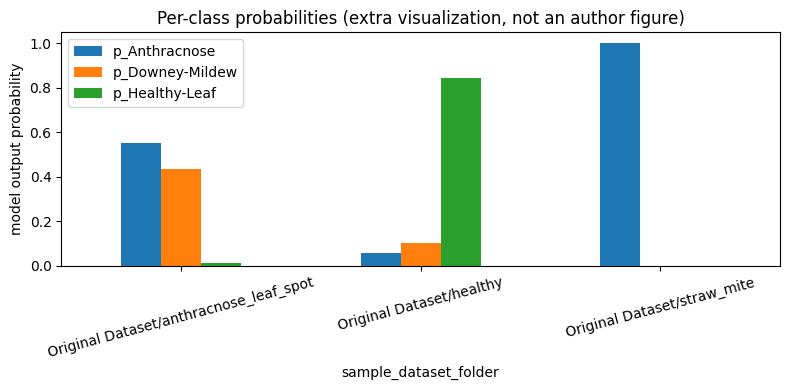

In [ ]:
import pandas as pd, csv

records = []
for folder, path in sample_map.items():
    arr = preprocess_image(open(path, "rb").read())
    probs = model.predict(arr, verbose=0)[0]
    served = dict(api_rows).get(folder) if False else dict((f, l) for f, c, l in api_rows).get(folder)
    records.append({
        "sample_dataset_folder": folder,
        "served_predicted_label": served,
        "direct_predicted_label": class_names.get(int(np.argmax(probs)), "Unknown"),
        "p_Anthracnose": float(probs[class_indices["Anthracnose"]]),
        "p_Downey-Mildew": float(probs[class_indices["Downey-Mildew"]]),
        "p_Healthy-Leaf": float(probs[class_indices["Healthy-Leaf"]]),
    })

df = pd.DataFrame(records)
df.to_csv("/content/predictions.csv", index=False)
print(df.to_string(index=False))

df.plot.bar(x="sample_dataset_folder", y=["p_Anthracnose", "p_Downey-Mildew", "p_Healthy-Leaf"],
            rot=15, figsize=(8, 4), title="Per-class probabilities (extra visualization, not an author figure)")
plt.ylabel("model output probability")
plt.tight_layout()
plt.savefig("/content/probabilities.png", dpi=110)
plt.show()

## 9. Interpretation, validation record, and limitations

**What was executed:** the authors' published `best_model.h5` (verified byte count) was loaded with the pinned pipeline and queried both directly and through the genuine FastAPI `POST /predict` served from the verbatim `main.py`; non-image uploads return HTTP 400 as documented. Results appear in the saved cell outputs above.

**Not verified:** the reported 81.3% test accuracy / per-class P/R/F1 (training logs and split not published), the ESP32/MQTT/ExpressJS/NextJS stages, and the 24h stress test. Dataset-folder labels are not asserted as the model's label space (`Straw_mite` vs `Downy-Mildew` mapping is the authors' undocumented choice). One example per dataset folder is a demonstration, not a benchmark.

**Reproduced from:** khatri-viren/flora-care-ai-server @ `0c3a72040ad171d1c30aa361538e61a70d3283fd`; MethodsX 15:103579 (PMCID PMC12423342); Mendeley Data n56pn9fncw v2 (CC BY 4.0). No LICENSE file was observed in the author repo; reuse terms must be verified separately.

*日本語:* 本ノートブックは推論サーブ経路(Stage 2C/2C.5)のみを再現しました。学習結果の再検証、IoT 機能、精度評価は対象外です。